In [2]:
df = pd.read_csv(r"C:\Users\meher\OneDrive\Desktop\Zomato Analysis\zomato.csv")

print(df.shape)
print(df.isnull().sum())

(51717, 17)
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [3]:
df.drop(columns=['url', 'address', 'phone', 'menu_item', 'reviews_list', 'dish_liked'], inplace=True)
df.shape

(51717, 11)

In [4]:
print(df.columns.tolist())
print(df['rate'].unique()[:20])

['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']
<StringArray>
['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5', '3.9/5',
 '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5', '4.3/5',   'NEW',
 '2.9/5', '3.5/5',     nan, '2.6/5']
Length: 20, dtype: str


In [5]:
df['rate'] = df['rate'].str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
print(df['rate'].dtype)
print(df['rate'].isnull().sum())

float64
10052


In [7]:
df['rate'] = df['rate'].fillna(df['rate'].mean())
print(df['rate'].isnull().sum())

0


In [8]:
print(df['approx_cost(for two people)'].unique()[:10])

<StringArray>
['800', '300', '600', '700', '550', '500', '450', '650', '400', '900']
Length: 10, dtype: str


In [9]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].mean())
print(df['approx_cost(for two people)'].dtype)
print(df['approx_cost(for two people)'].isnull().sum())

float64
0


In [10]:
print(df['location'].value_counts().head(10))

location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64


In [11]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.107408
St. Marks Road           4.009102
Koramangala 3rd Block    3.983385
Koramangala 5th Block    3.983260
Church Street            3.980334
Sankey Road              3.955572
Cunningham Road          3.894516
Koramangala 4th Block    3.880904
Rajarajeshwari Nagar     3.850000
Residency Road           3.846713
Name: rate, dtype: float64

In [12]:
df['cuisines'].value_counts().head(10)

cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Name: count, dtype: int64

In [13]:
df.groupby('location')['approx_cost(for two people)'].mean().sort_values(ascending=False).head(10)

location
Rajarajeshwari Nagar     725.000000
Nagarbhavi               538.888889
Race Course Road         536.670135
Infantry Road            526.803036
Church Street            500.307041
Kengeri                  500.000000
Old Madras Road          488.636364
St. Marks Road           487.913986
Sadashiv Nagar           480.941937
Koramangala 3rd Block    480.927819
Name: approx_cost(for two people), dtype: float64

In [14]:
df['online_order'].value_counts()

online_order
Yes    30444
No     21273
Name: count, dtype: int64

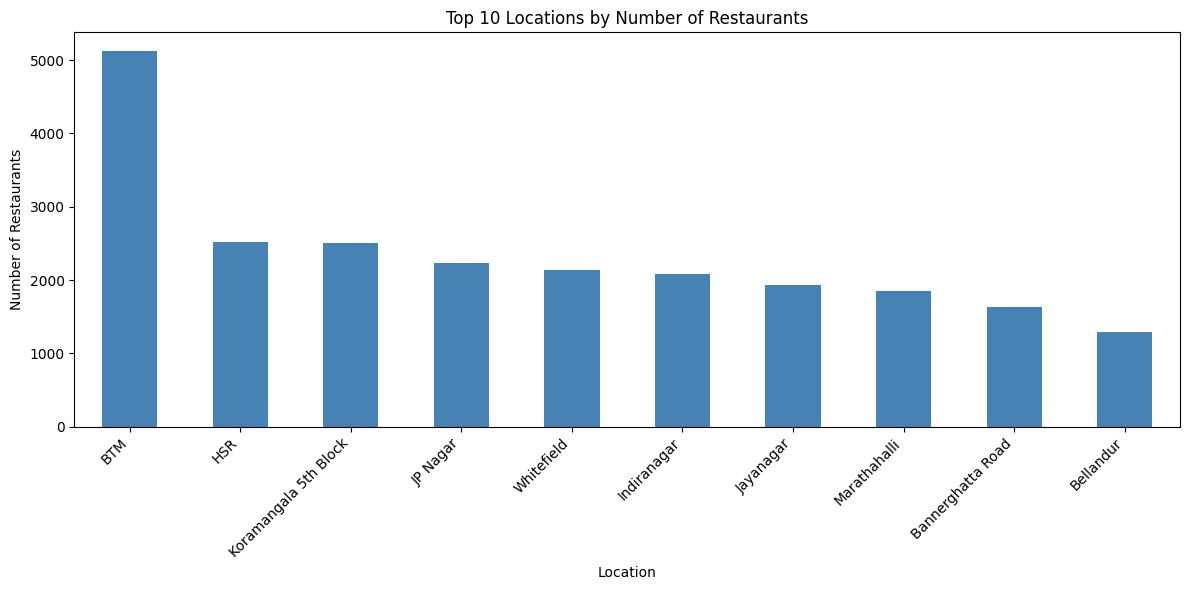

In [21]:
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

top_locations.plot(kind='bar', figsize=(12,6), color='steelblue')
plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

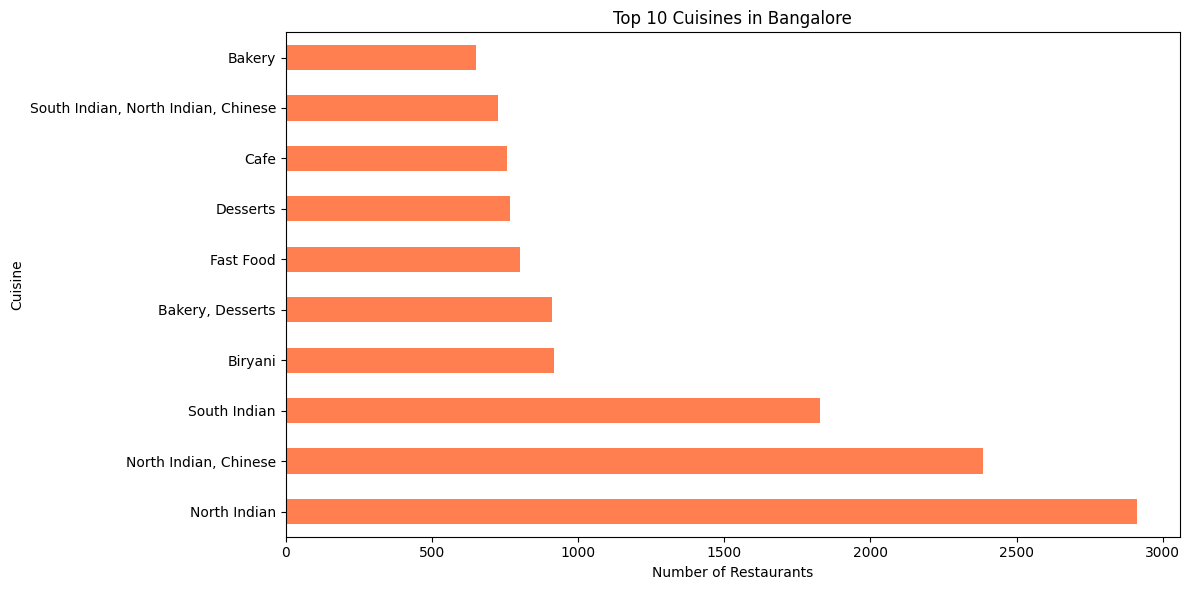

In [18]:
# Top 10 cuisines
top_cuisines = df['cuisines'].value_counts().head(10)

top_cuisines.plot(kind='barh', figsize=(12,6), color='coral')
plt.title('Top 10 Cuisines in Bangalore')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

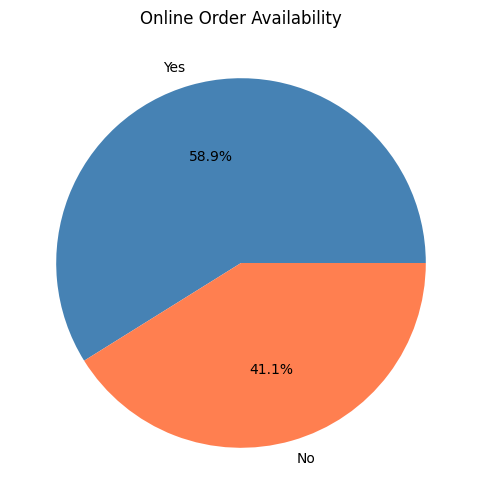

In [19]:
df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['steelblue', 'coral'])
plt.title('Online Order Availability')
plt.ylabel('')
plt.show()